# 09 Floating point 16 training issues. 

### Take a look at this:

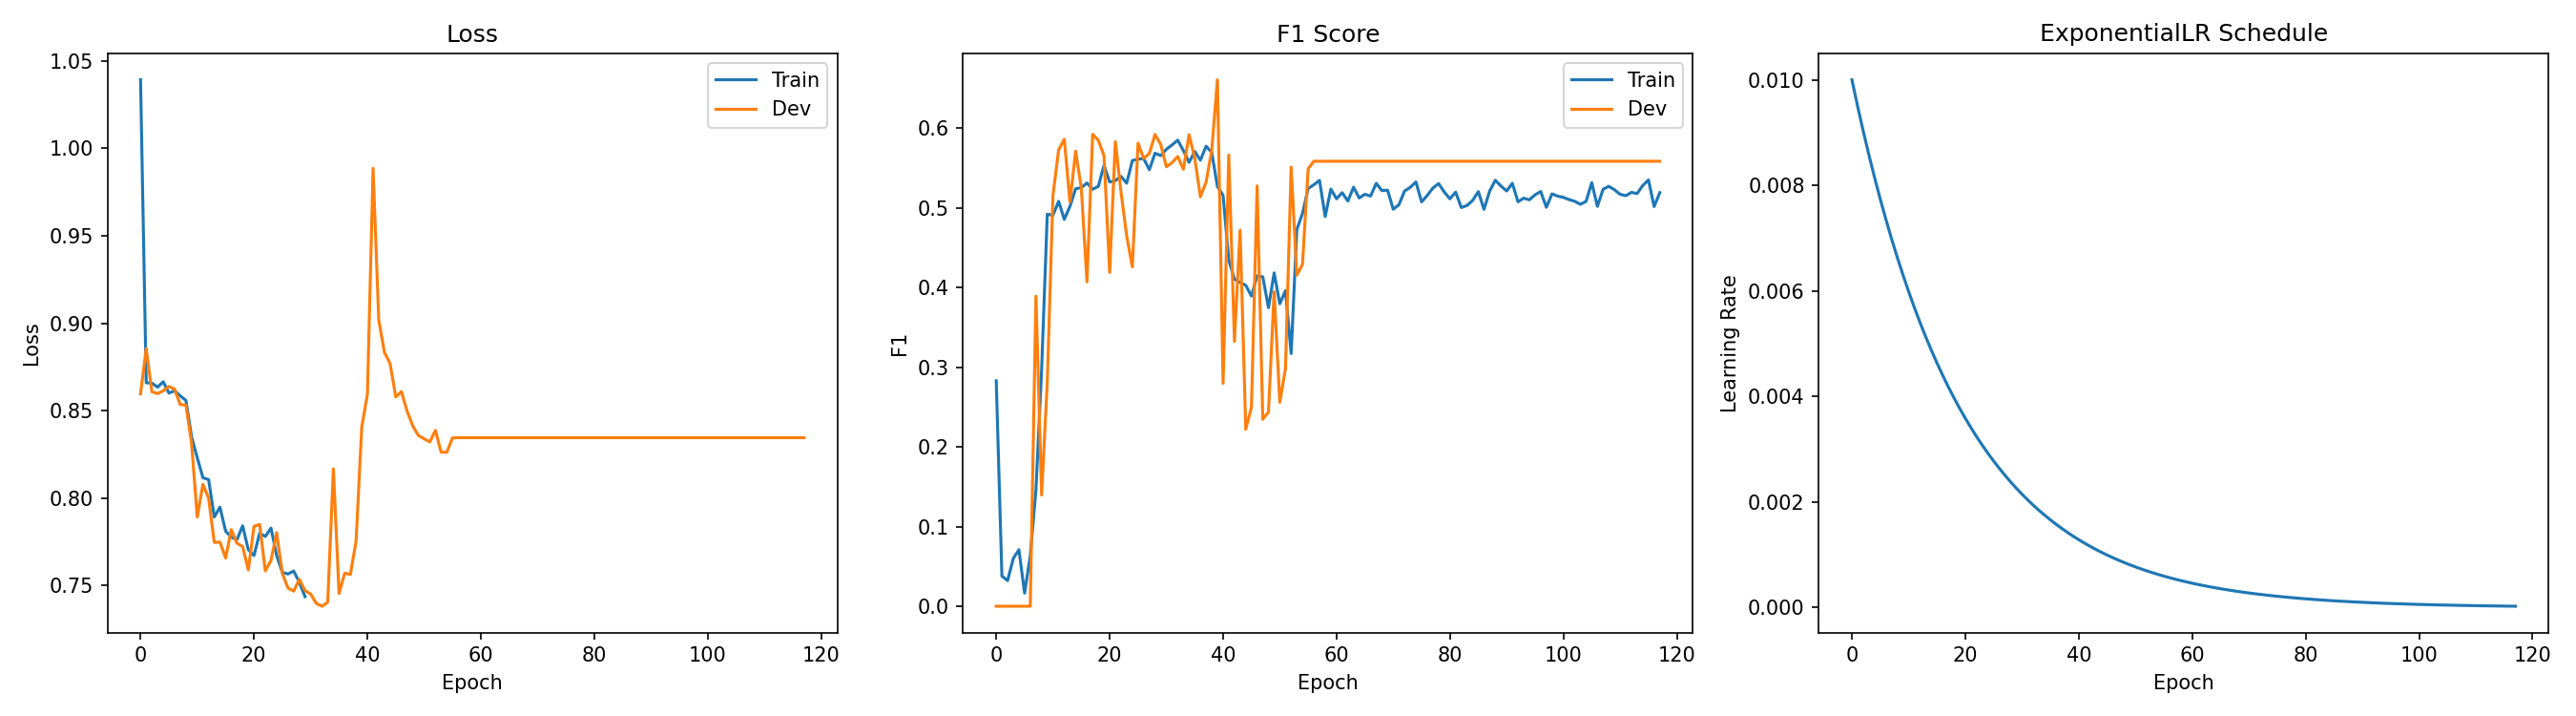

That's one interesting loss curve there. 

Here is the training log from A different training run, but same thing happened:

```                                       
Epoch  30/150 | LR 0.002259 | Train Loss 0.7436 F1 0.5658 | Dev Loss 0.7471 F1 0.5799
.........
Epoch  39/150 | LR 0.001424 | Train Loss nan F1 0.5699 | Dev Loss 0.7753 F1 0.5726
Epoch  40/150 | LR 0.001353 | Train Loss nan F1 0.5269 | Dev Loss 0.8405 F1 0.6610 
Epoch  41/150 | LR 0.001285 | Train Loss nan F1 0.5159 | Dev Loss 0.8594 F1 0.2798  
Epoch  42/150 | LR 0.001221 | Train Loss nan F1 0.4347 | Dev Loss 0.9886 F1 0.5667  
Epoch  43/150 | LR 0.001160 | Train Loss nan F1 0.4106 | Dev Loss 0.9018 F1 0.3325  
Epoch  44/150 | LR 0.001102 | Train Loss nan F1 0.4067 | Dev Loss 0.8834 F1 0.4722
```

**THE TRAIN LOSS GOES TO NAN ?**


Three questions become apparent: 
1) Why do we stop plotting train loss?
2) Why do we get worse dev-and-train F1?
3) Why does dev-F1 performance plateau?

Could this somehow have to do with the fact that we're forgetting an element in the array, so if to an array and we're trying to divide by an empty array?

In [ ]:
55 / len([])

ZeroDivisionError: division by zero

That's not it because we're getting a different type of error that's not returning nan. 

Some things to note here: 
- I'm training with mixed precision, so the output of the model is in float16, not float32. 
- I do not have dropout (or weight decay in optim) in the linear layer, so my model's final layer is likely outputting large logits since the weights in the last layer are getting larger as trainign goes on.



My model def:
```Python        
x = self.block5(x)  # (B, 256, D, H, W)
x = self.gap(x)     # (B, 256, 1, 1, 1)
x = x.view(x.size(0), -1)  # (B, 256)
return self.fc(x)   # (B, num_classes)
        
```



Note the answer is here:

```Python
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

....

with torch.amp.autocast(device_type='cuda'):
    logits = model(X)
loss = criterion(logits, y)
```

As I have noted, I'm training with mixed precision and I'm using binary cross-entropy loss. 

Let's look at what our loss looks like if our load just gets very large, depending on if we have float16 or float32. 

In [3]:
from torch.nn import BCEWithLogitsLoss
import torch

criterion = BCEWithLogitsLoss()


criterion(torch.tensor([100000.0, 1000.0], dtype=torch.float32), torch.tensor([1.0, 0.0]))

tensor(500.)

Okay, that looks good. We've got a valid loss value. 

In [5]:
criterion(torch.tensor([100000.0, 1000.0], dtype=torch.float16), torch.tensor([1.0, 0.0]))

tensor(nan)

Ah, we have found it!!!!!

____

nap + anything = nan (when one batches loss is nan all the rest are)

And Matplotlib doesn't plot nan values, so that's why train loss disappears. 

____


We're having floating point overflow when we try and compute the loss in Float 16. To fix this, we need to do something like this. \\
``` Python

with torch.amp.autocast(device_type='cuda'):
    logits = model(X)
# Compute loss in FP32 to avoid FP16 overflow in log-sum-exp
loss = criterion(logits.float(), y)

```

### Now for questions two and three. 

These really just have to do with the training dynamics that happen after we We start to have this overflow happen. 

**2:**


We don't update the weights of the network on the batches that have *NAN* loss, but not all of them do. So we just update the weights according to the batches that didn't have *NAN*. They usually probably have very large logits, but not overflowing. So we have large weight updates and these weight updates that cause the network to overfit, and the overfitting causes us to do less well on the dev data. And that is why we are doing more variability in the DEV data. 

We can still clac F1 scores, so that is why you see the DEV F1 go down and become very variable. Because not only are we training on only some of the batches, but also we have large weight updates on those batches.


**3:**

So then for question 3, we just get the following: 

The model just collapses and predicts probably only one class. So that's why you see the F1 score not change at all. It's probably just our majority class, and the model has collapsed. 